# Operating Conditions Analysis

## Objective

The NASA CMAPSS dataset contains three operational setting variables that describe the engine's operating regime.

The purpose of this notebook is to investigate how operating conditions affect sensor measurements.

The analysis aims to answer the following questions:

- How many operating conditions exist?
- Are operating conditions continuous or clustered?
- Which sensors are influenced by operational settings?
- Could operating conditions explain some of the observed sensor variability?

Understanding these relationships will help distinguish operational effects from degradation effects before feature engineering and model development.

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH,
)

In [5]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-21 12:18:21 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-21 12:18:25 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-21 12:18:25 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-21 12:18:28 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-21 12:18:28 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-21 12:18:28 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-21 12:18:28 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-21 12:18:28 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-21 12:18:28 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

In [6]:
settings = [
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

train_df[settings].describe()

,operational_setting_1,operational_setting_2,operational_setting_3
count,61249.000000,61249.000000,61249.000000
mean,23.999823,0.571347,94.031576
std,14.780722,0.310703,14.251954
min,0.000000,0.000000,60.000000
25%,10.004600,0.250700,100.000000
50%,25.001400,0.700000,100.000000
75%,41.998100,0.840000,100.000000
max,42.008000,0.842000,100.000000


In [7]:
train_df[settings].nunique()

operational_setting_1    536
operational_setting_2    105
operational_setting_3      2
dtype: int64

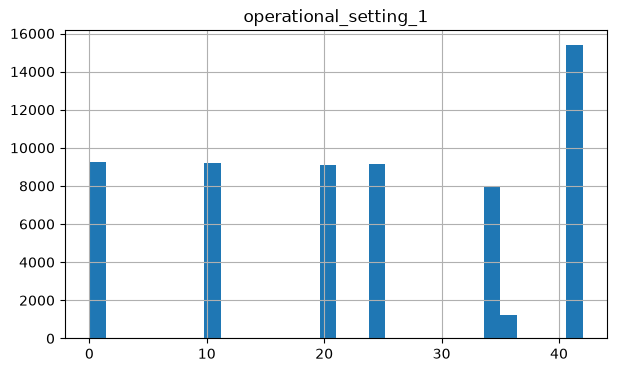

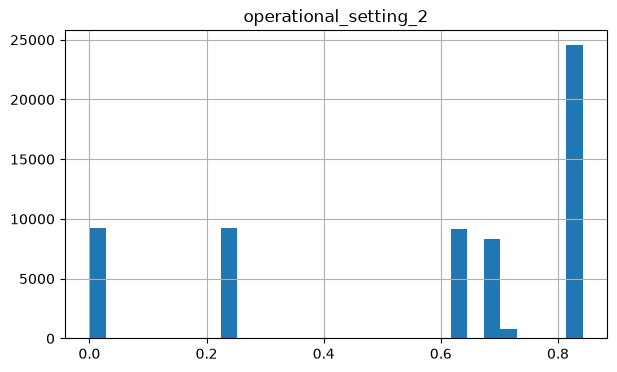

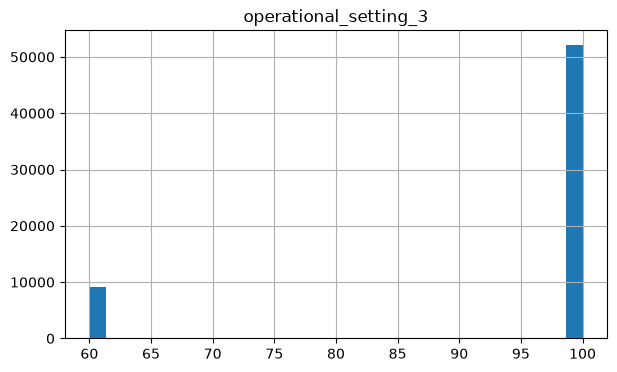

In [8]:
for setting in settings:

    plt.figure(figsize=(7,4))

    plt.hist(
        train_df[setting],
        bins=30
    )

    plt.title(setting)
    plt.grid(True)
    plt.show()

### Pairwise Scatter Plots

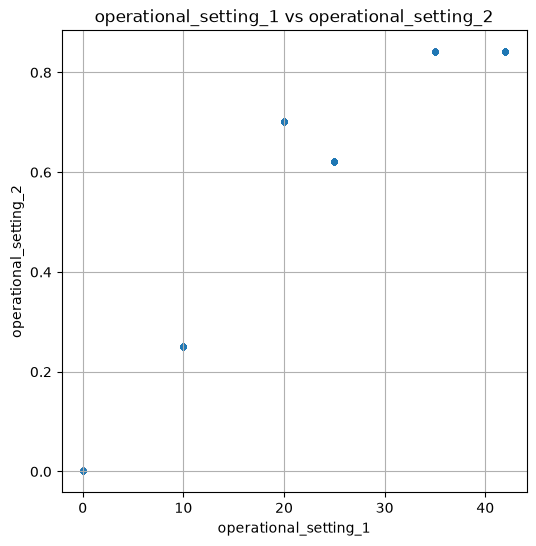

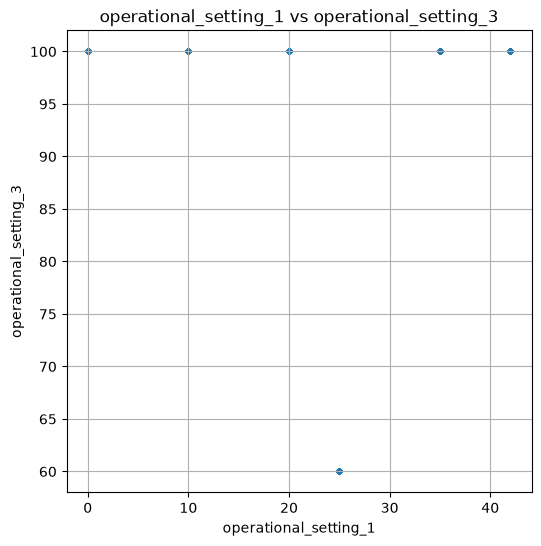

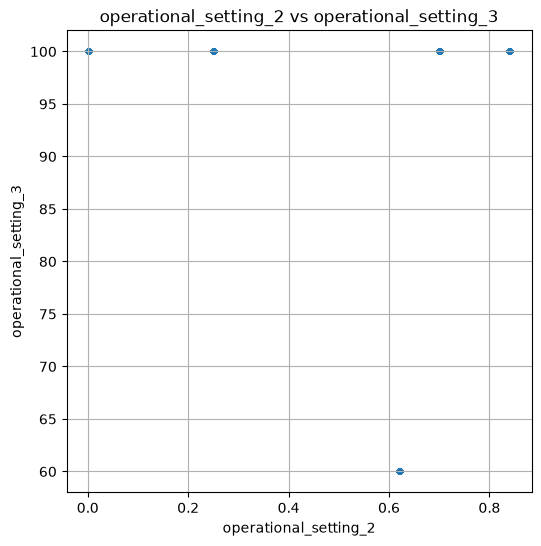

In [9]:
pairs = [
    ("operational_setting_1", "operational_setting_2"),
    ("operational_setting_1", "operational_setting_3"),
    ("operational_setting_2", "operational_setting_3"),
]

for x, y in pairs:

    plt.figure(figsize=(6,6))

    plt.scatter(
        train_df[x],
        train_df[y],
        alpha=0.3,
        s=8
    )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.grid(True)
    plt.show()

### Correlation Between Operational Settings

In [10]:
train_df[settings].corr()

,operational_setting_1,operational_setting_2,operational_setting_3
operational_setting_1,1.000000,0.943796,-0.028425
operational_setting_2,0.943796,1.000000,-0.066257
operational_setting_3,-0.028425,-0.066257,1.000000


### Relationship Between Operational Settings and Sensors

In [11]:
sensor_columns = [
    c
    for c in train_df.columns
    if c.startswith("sensor")
]

corr = train_df[
    settings + sensor_columns
].corr()

setting_sensor_corr = corr.loc[
    settings,
    sensor_columns
]

setting_sensor_corr

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
operational_setting_1,-0.964754,-0.868390,-0.787848,-0.839988,-0.987382,-0.976518,-0.951582,-0.444728,-0.776800,-0.823819,...,-0.951158,-0.028443,-0.263960,0.460800,-0.840823,-0.790694,-0.444336,-0.028425,-0.962043,-0.962052
operational_setting_2,-0.886123,-0.811613,-0.761372,-0.837055,-0.933693,-0.929548,-0.919006,-0.440914,-0.754337,-0.882565,...,-0.918868,-0.066236,-0.356085,0.520309,-0.902160,-0.764491,-0.440552,-0.066257,-0.922004,-0.922000
operational_setting_3,0.163835,0.478659,0.620181,0.544482,0.113471,0.197793,0.306687,0.902625,0.634634,0.514065,...,0.308038,0.999998,0.928067,-0.881196,0.290752,0.616473,0.902830,1.000000,0.276239,0.276147


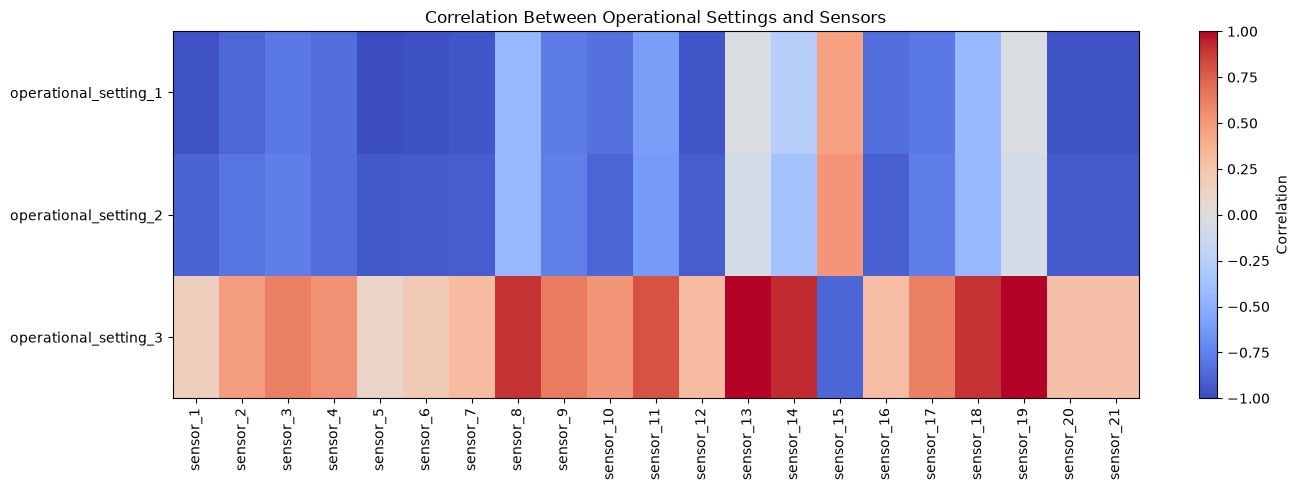

In [12]:
plt.figure(figsize=(14,5))

plt.imshow(
    setting_sensor_corr,
    cmap="coolwarm",
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(sensor_columns)),
    sensor_columns,
    rotation=90
)

plt.yticks(
    range(len(settings)),
    settings
)

plt.title("Correlation Between Operational Settings and Sensors")

plt.tight_layout()

plt.show()

In [13]:
max_corr = setting_sensor_corr.abs().max()

max_corr.sort_values(
    ascending=False
)

sensor_19    1.000000
sensor_13    0.999998
sensor_5     0.987382
sensor_6     0.976518
sensor_1     0.964754
sensor_21    0.962052
sensor_20    0.962043
sensor_7     0.951582
sensor_12    0.951158
sensor_14    0.928067
sensor_18    0.902830
sensor_8     0.902625
sensor_16    0.902160
sensor_10    0.882565
sensor_15    0.881196
sensor_2     0.868390
sensor_4     0.839988
sensor_11    0.798813
sensor_17    0.790694
sensor_3     0.787848
sensor_9     0.776800
dtype: float64

In [14]:
max_corr.to_csv(
    "../reports/operational_setting_sensor_correlation.csv"
)

# Observations

## Operational Settings Overview

The NASA CMAPSS dataset contains three operational setting variables describing the engine operating regime.

Their statistical properties indicate that they do not contribute equally.

---

## Operational Setting 1

Operational Setting 1 spans a wide continuous range (0 to approximately 42), indicating substantial variation across operating conditions.

---

## Operational Setting 2

Operational Setting 2 also varies continuously, although within a much smaller numerical range.

Scatter plot analysis reveals a strong linear relationship between Operational Setting 1 and Operational Setting 2.

This suggests that both variables describe closely related aspects of the engine operating regime.

---

## Operational Setting 3

Operational Setting 3 exhibits very limited variability.

Most observations are concentrated at the value 100, with relatively few observations below this value.

Scatter plots show little apparent relationship between Operational Setting 3 and the other operational settings.

Consequently, Operational Setting 3 appears to contribute less variability than the other two settings.

---

## Interpretation

The operational settings are not equally informative.

Operational Settings 1 and 2 appear to describe the primary operating regime, while Operational Setting 3 contributes comparatively little variation.

This difference should be considered during feature engineering and model development.

# Engineering Decisions

## Decision 1 — Preserve All Operational Settings

No operational setting will be removed during the EDA stage.

Although Operational Setting 3 exhibits limited variability, its predictive contribution will be evaluated during feature selection.

---

## Decision 2 — Investigate Redundancy

The strong linear relationship between Operational Settings 1 and 2 suggests potential redundancy.

Further analysis will determine whether both variables are required for predictive modeling.

---

## Decision 3 — Include Operational Settings in Modeling

Operational settings will be retained as input features because they describe the engine's operating regime and may influence sensor measurements independently of degradation.

---

## Decision 4 — Separate Operating Effects from Degradation

Future analyses will distinguish between changes caused by operating conditions and changes caused by engine degradation to avoid misleading feature importance estimates.